# Baseline

## Общая инициализация
Нужно выполнить в самом начале независимо от дальнейших действий

### Путь к каталогу, в котором лежит датасет
датасет представлен файлом `train.csv` и папкой `train`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_folder = "audio_files/train"
train_csv = "audio_files/train.csv"

In [ ]:
base_folder = "/content/drive/MyDrive/Colab Notebooks/DSP_2sem/lab3_cnn"  # или /lab3_cnn

#### Инициализация путей

In [ ]:
import os.path as path

In [ ]:
import os
import random

import librosa
import librosa.feature as F

import numpy as np

import matplotlib.pyplot as plt

from IPython.display import Audio

In [ ]:
train_folder = os.path.join(base_folder, "train")
train_csv = os.path.join(base_folder, "train.csv")
train_pickle = os.path.join(base_folder, "train.pickle")
labels_pickle = os.path.join(base_folder, "labels.pickle")

In [ ]:
import os
import random
import librosa


# Диагностика
print("=== ПРОВЕРКА ПУТЕЙ ===")
print(f"base_folder существует: {os.path.exists(base_folder)}")
print(f"train_folder существует: {os.path.exists(train_folder)}")
print(f"train_csv существует: {os.path.exists(train_csv)}")
print(f"train_pickle существует: {os.path.exists(train_pickle)}")
print(f"labels_pickle существует: {os.path.exists(labels_pickle)}")

if os.path.exists(train_folder):
    # Получаем только аудиофайлы (исключаем подпапки)
    all_files = os.listdir(train_folder)
    audio_files = [f for f in all_files if f.endswith(('.wav', '.mp3', '.flac', '.ogg'))]

    print(f"\nВсего файлов в train: {len(all_files)}")
    print(f"Аудиофайлов: {len(audio_files)}")
    print(f"Примеры: {all_files[:5]}")

    if audio_files:
        # Выбираем случайный аудиофайл
        filename = random.choice(audio_files)
        print(f"\n✅ Выбран файл: {filename}")

        # Пробуем загрузить
        file_path = os.path.join(train_folder, filename)
        try:
            wav, sr = librosa.load(file_path, sr=16000)
            print(f"Загружено: {len(wav)} отсчетов, sr={sr} Гц")
            print(f"Длительность: {len(wav)/sr:.2f} сек")
            print(f"Тип данных: {wav.dtype}")
            print(f"Диапазон значений: [{wav.min():.3f}, {wav.max():.3f}]")
        except Exception as e:
            print(f"❌ Ошибка загрузки: {e}")
    else:
        print("\n❌ В папке train нет аудиофайлов!")
else:
    print("\n❌ Папка train не найдена!")
    if os.path.exists(base_folder):
        print(f"Содержимое base_folder: {os.listdir(base_folder)}")
    else:
        print(f"base_folder не существует: {base_folder}")

=== ПРОВЕРКА ПУТЕЙ ===
base_folder существует: True
train_folder существует: True
train_csv существует: True
train_pickle существует: True
labels_pickle существует: True

Всего файлов в train: 5683
Аудиофайлов: 5683
Примеры: ['c1bd26b116192744c164.wav', 'cfa0eccb539051d7d1b1.wav', '6253b01da2c64ea20261.wav', '7ee2fa0ff641deffdeb0.wav', '8c784380b70403a66451.wav']

✅ Выбран файл: e420c2efcb659128d11c.wav
Загружено: 134720 отсчетов, sr=16000 Гц
Длительность: 8.42 сек
Тип данных: float32
Диапазон значений: [-1.031, 1.027]


### Изучение аудиофайлов датасета

#### Спектрограмма

In [ ]:
sample_rate = 16000
duration = 2.0
n_fft = 2048
overlap = 4
hop_length = n_fft // overlap  # 512

# Для обычной спектрограммы НЕ НУЖЕН n_mels!
# n_mels используется ТОЛЬКО для MEL-спектрограммы

target_length = int(sample_rate * duration)
n_frames = 1 + (target_length - n_fft) // hop_length
n_freq_bins = n_fft // 2 + 1  # 1025

print(f"Размер спектрограммы: ({n_freq_bins}, {n_frames})")

Размер ОБЫЧНОЙ спектрограммы: (1025, 59)


Загружено: 32000 отсчетов, sr=16000 Гц, длительность: 2.00 сек


/tmp/ipykernel_21414/3476831285.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


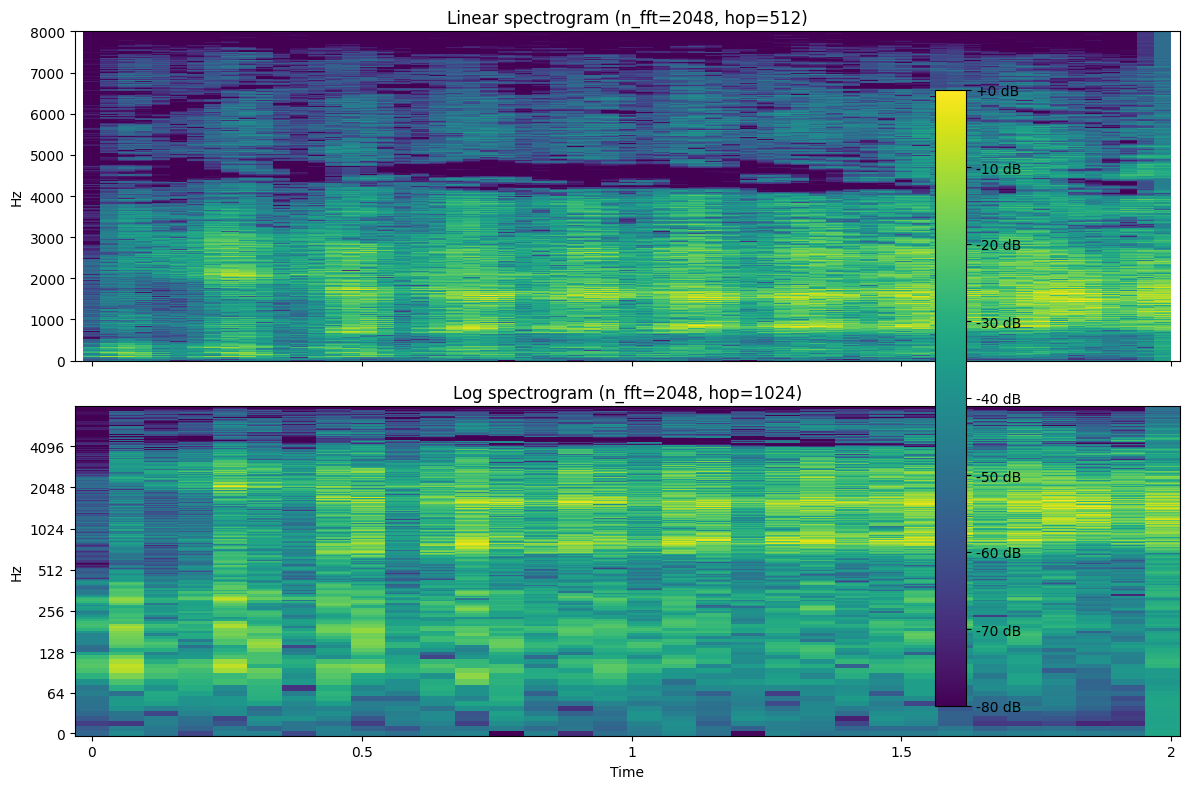

In [ ]:
wav_data, sr = librosa.load(
    os.path.join(train_folder, filename),
    sr=sample_rate,
    duration=2.0
)

print(f"Загружено: {len(wav_data)} отсчетов, sr={sr} Гц, длительность: {len(wav_data)/sr:.2f} сек")

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

# Линейная спектрограмма
hop_length = 512
D_linear = np.abs(librosa.stft(wav_data, n_fft=2048, hop_length=hop_length))
D_linear_db = librosa.amplitude_to_db(D_linear, ref=np.max)

# ВАЖНО: сохранить возвращаемое значение specshow в переменную
img1 = librosa.display.specshow(
    D_linear_db,
    sr=sr,
    hop_length=hop_length,
    ax=ax_top,
    x_axis='time',
    y_axis='linear',
    cmap='viridis'
)
ax_top.set(title=f'Linear spectrogram (n_fft=2048, hop={hop_length})')
ax_top.label_outer()

# Логарифмическая спектрограмма
hop_length_log = 1024
D_log = np.abs(librosa.stft(wav_data, n_fft=2048, hop_length=hop_length_log))
D_log_db = librosa.amplitude_to_db(D_log, ref=np.max)

img2 = librosa.display.specshow(
    D_log_db,
    sr=sr,
    hop_length=hop_length_log,
    ax=ax_bottom,
    x_axis='time',
    y_axis='log',
    cmap='viridis'
)
ax_bottom.set(title=f'Log spectrogram (n_fft=2048, hop={hop_length_log})')
ax_bottom.label_outer()

# ИСПРАВЛЕНО: используем img1 для colorbar (или img2)
fig.colorbar(img1, ax=[ax_top, ax_bottom], format="%+2.f dB")
plt.tight_layout()
plt.show()

# Прослушивание
display(Audio(wav_data, rate=sr))

#### Mel-спектрограмма

In [ ]:
"""
mel_spec = librosa.feature.melspectrogram(
    y=wav_data,
    sr=16000,
    n_fft=2048,
    hop_length=512,
    n_mels=64
)
print(mel_spec.shape)  # (64, 59)

# Визуализация
librosa.display.specshow(mel_spec, sr=16000, hop_length=512, y_axis='mel')
"""
sample_rate = 16000
n_fft = 2048
hop_length = 512
n_mels = 64
TARGET_DURATION = 2.0
TARGET_LENGTH = int(sample_rate * TARGET_DURATION)  # 32000
MAX_FRAMES = 1 + (TARGET_LENGTH - n_fft) // hop_length

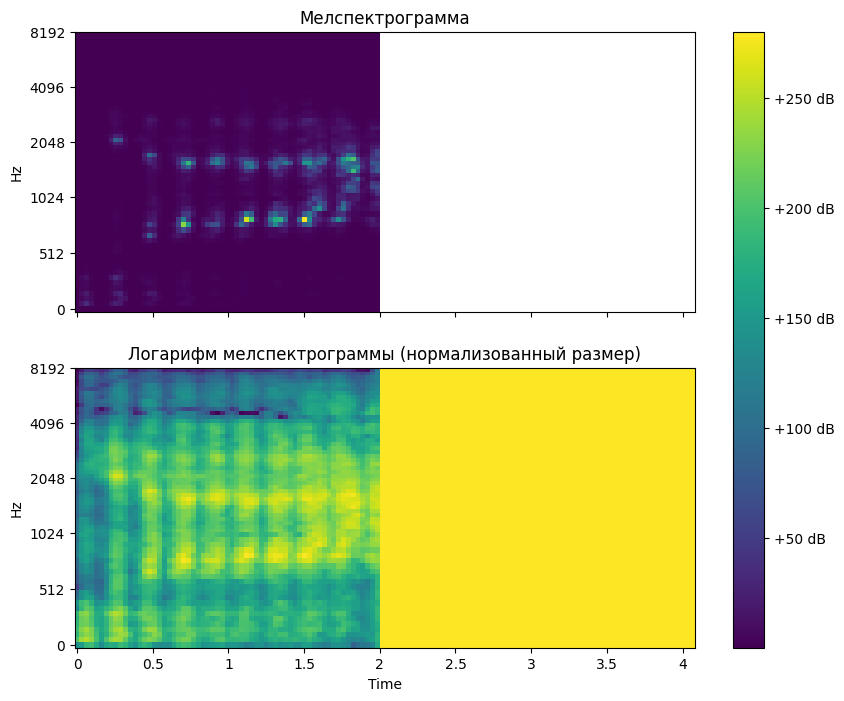

Форма после обработки: (64, 128)


In [ ]:
# загрузка БЕЗ автоматического ресемплинга
wav_data, sr = librosa.load(os.path.join(train_folder, filename), sr=None)

# ресемплинг до 16 kHz
wav_data = librosa.resample(wav_data, orig_sr=sr, target_sr=sample_rate)
sr = sample_rate

# фиксируем длительность 2 секунды
TARGET_DURATION = 2
TARGET_LENGTH = sample_rate * TARGET_DURATION  # 32000

if len(wav_data) > TARGET_LENGTH:
    wav_data = wav_data[:TARGET_LENGTH]
else:
    wav_data = np.pad(wav_data, (0, TARGET_LENGTH - len(wav_data)))

# mel-спектрограмма (сохраняем "физические" параметры)
mel_spec = F.melspectrogram(
    y=wav_data,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    fmax=sample_rate // 2
)

# логарифм
D = librosa.power_to_db(mel_spec, ref=np.max)

# --- НОВОЕ: нормализация размера ---
MAX_FRAMES = 128

if D.shape[1] < MAX_FRAMES:
    D = np.pad(D, ((0, 0), (0, MAX_FRAMES - D.shape[1])))
else:
    D = D[:, :MAX_FRAMES]

# --- ВИЗУАЛИЗАЦИЯ ---
fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
cmap = "viridis"

img1 = librosa.display.specshow(
    mel_spec,
    sr=sr,
    fmax=sr // 2,
    ax=ax_top,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax_top.set(title='Мелспектрограмма')
ax_top.label_outer()

img2 = librosa.display.specshow(
    D,
    sr=sr,
    fmax=sr // 2,
    ax=ax_bottom,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax_bottom.set(title='Логарифм мелспектрограммы (нормализованный размер)')
ax_bottom.label_outer()

fig.colorbar(img1, ax=[ax_top, ax_bottom], format="%+2.f dB")
plt.show()

print("Форма после обработки:", D.shape)

display(Audio(wav_data, rate=sr))

## Извлечение признаков

In [ ]:
import os
import pickle
from enum import Enum
from typing import Optional
from tqdm import tqdm
import pandas as pd
import numpy as np
import librosa

In [ ]:

class SetType(Enum):
    """Set type"""
    TRAIN = 1
    TEST  = 2
    DEV   = 3

def extract_log_mel_feats(set_type:SetType, path_to_csv:str, path_to_files:str,
                          out_path:str, labels_pickle:str, sr:Optional[int],
                          n_fft:int, hop_length:int, n_mels:int,
                          duration:float = 2.0, target_frames:int = None):
    """
    Extract features from given files and store them in binary format.

    :param set_type: set type (TRAIN or TEST)
    :param path_to_csv: path to loaded csv
    :param path_to_files: path to loaded data
    :param out_path: path to store extracted features
    :param labels_pickle: path to store labels dictionary
    :param sr: target sample rate (16000)
    :param n_fft: size of fft window (2048)
    :param hop_length: hop size (512)
    :param n_mels: number of mel bands (64)
    :param duration: audio duration in seconds (2.0)
    :param target_frames: fixed number of frames (auto-calculated if None)
    """
    if set_type not in [SetType.TRAIN, SetType.TEST]:
        raise Exception(f'Such set type not supported: {set_type}')

    # Рассчитываем TARGET_LENGTH (количество отсчетов)
    TARGET_LENGTH = int(sr * duration)  # 16000 * 2 = 32000

    # Рассчитываем MAX_FRAMES (количество кадров в спектрограмме)
    if target_frames is None:
        MAX_FRAMES = 1 + (TARGET_LENGTH - n_fft) // hop_length  # 1 + (32000-2048)//512 = 59
    else:
        MAX_FRAMES = target_frames

    print(f"Параметры извлечения признаков:")
    print(f"  Sample rate: {sr} Гц")
    print(f"  Duration: {duration} сек")
    print(f"  Target length: {TARGET_LENGTH} отсчетов")
    print(f"  Max frames: {MAX_FRAMES}")
    print(f"  n_fft: {n_fft}, hop_length: {hop_length}, n_mels: {n_mels}")

    feats = []

    if set_type == SetType.TRAIN:
        meta = pd.read_csv(path_to_csv, skiprows=1, names=['fname', 'label'])

        file_names = list(meta['fname'])
        n_files = len(file_names)
        labels = list(meta['label'])

        uniq_labels = np.sort(np.unique(labels))
        label_to_id = {label: i for i, label in enumerate(uniq_labels)}

        print('Total files:', n_files)

        for i, (file_name, label) in tqdm(enumerate(zip(file_names, labels)), total=n_files):
            # Загружаем с оригинальной частотой (sr=None)
            wav_data, orig_sr = librosa.load(os.path.join(path_to_files, file_name), sr=None)

            # Ресемплируем до target sr (16000)
            wav_data = librosa.resample(wav_data, orig_sr=orig_sr, target_sr=sr)

            # Обрезаем или дополняем до TARGET_LENGTH
            if len(wav_data) > TARGET_LENGTH:
                wav_data = wav_data[:TARGET_LENGTH]
            else:
                wav_data = np.pad(wav_data, (0, TARGET_LENGTH - len(wav_data)))

            # Вычисляем MEL-спектрограмму
            mel_spec = librosa.feature.melspectrogram(
                y=wav_data,
                sr=sr,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                fmax=sr // 2
            )

            # Переводим в децибелы
            log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

            # Обрезаем или дополняем до MAX_FRAMES
            if log_mel_spec.shape[1] < MAX_FRAMES:
                log_mel_spec = np.pad(log_mel_spec, ((0, 0), (0, MAX_FRAMES - log_mel_spec.shape[1])))
            else:
                log_mel_spec = log_mel_spec[:, :MAX_FRAMES]

            feats.append({
                'fname': file_name,
                'feature': log_mel_spec,
                'label_id': label_to_id[label]
            })

        pickle.dump(feats, open(out_path, 'wb'))
        pickle.dump(label_to_id, open(labels_pickle, 'wb'))
        return label_to_id

    else:  # TEST or DEV
        file_names = os.listdir(path_to_files)
        print(f'Total files in {set_type}:', len(file_names))

        for i, file_name in tqdm(enumerate(file_names), total=len(file_names)):
            # Загружаем с оригинальной частотой
            wav_data, orig_sr = librosa.load(os.path.join(path_to_files, file_name), sr=None)

            # Ресемплируем до target sr
            wav_data = librosa.resample(wav_data, orig_sr=orig_sr, target_sr=sr)

            # Обрезаем или дополняем до TARGET_LENGTH
            if len(wav_data) > TARGET_LENGTH:
                wav_data = wav_data[:TARGET_LENGTH]
            else:
                wav_data = np.pad(wav_data, (0, TARGET_LENGTH - len(wav_data)))

            # Вычисляем MEL-спектрограмму
            mel_spec = librosa.feature.melspectrogram(
                y=wav_data,
                sr=sr,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                fmax=sr // 2
            )

            # Переводим в децибелы
            log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

            # Обрезаем или дополняем до MAX_FRAMES
            if log_mel_spec.shape[1] < MAX_FRAMES:
                log_mel_spec = np.pad(log_mel_spec, ((0, 0), (0, MAX_FRAMES - log_mel_spec.shape[1])))
            else:
                log_mel_spec = log_mel_spec[:, :MAX_FRAMES]

            feats.append({
                'fname': file_name,
                'feature': log_mel_spec,
            })

        pickle.dump(feats, open(out_path, 'wb'))
        return

In [ ]:
# feature extraction parameters
sample_rate = 16000
n_fft = 2048
hop_length = 512
n_mels = 64
TARGET_DURATION = 2.0
TARGET_LENGTH = int(sample_rate * TARGET_DURATION)  # 32000
MAX_FRAMES = 1 + (TARGET_LENGTH - n_fft) // hop_length

print(f"sample_rate: {sample_rate}")
print(f"n_fft: {n_fft}")
print(f"hop_length: {hop_length}")
print(f"n_mels: {n_mels}")
print(f"TARGET_DURATION: {TARGET_DURATION}")
print(f"TARGET_LENGTH: {TARGET_LENGTH}")
print(f"MAX_FRAMES: {MAX_FRAMES}")

sample_rate: 16000
n_fft: 2048
hop_length: 512
n_mels: 64
TARGET_DURATION: 2.0
TARGET_LENGTH: 32000
MAX_FRAMES: 59


In [ ]:
# extract features and store to `train_pickle`
label_to_id = extract_log_mel_feats(
    set_type=SetType.TRAIN,
    path_to_csv=train_csv,
    path_to_files=train_folder,
    out_path=train_pickle,
    labels_pickle=labels_pickle,
    sr=sample_rate,        # 16000
    n_fft=n_fft,           # 2048
    hop_length=hop_length, # 512
    n_mels=n_mels,         # 64
    duration=TARGET_DURATION,     # 2.0
    target_frames=MAX_FRAMES      # 59
)

# Создаем обратный словарь
id_to_label = [label for label, i in label_to_id.items()]

print(f"Извлечено {len(label_to_id)} классов")
print(f"Классы: {id_to_label[:5]}...")  # первые 5 классов

Параметры извлечения признаков:
  Sample rate: 16000 Гц
  Duration: 2.0 сек
  Target length: 32000 отсчетов
  Max frames: 59
  n_fft: 2048, hop_length: 512, n_mels: 64
Total files: 5683


100%|██████████| 5683/5683 [01:38<00:00, 57.81it/s]


Извлечено 41 классов
Классы: [np.str_('Acoustic_guitar'), np.str_('Applause'), np.str_('Bark'), np.str_('Bass_drum'), np.str_('Burping_or_eructation')]...


## Алгоритм детектирования

### Подготовительный этап

In [ ]:
from typing import NoReturn
from pprint import pprint
import random

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as T

In [ ]:
device = device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
cpu_count = os.cpu_count()

num_workers = cpu_count if device == "cpu" else 0
num_workers, cpu_count

(0, 2)

#### Добиваемся максимальной воспроизводимости
Согласно данному мануалу: https://pytorch.org/docs/stable/notes/randomness.html

In [ ]:
def set_random_state(random_state:int=0) -> NoReturn:
    """Initialize random generators.

    Parameters
    ==========
    random_state : int = 0
        Determines random number generation for centroid initialization.
        Use an int to make the randomness deterministic.
    """
    torch.manual_seed(random_state)
    random.seed(random_state)
    np.random.seed(random_state)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        torch.cuda.manual_seed(random_state)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [ ]:
random_state = 42

In [ ]:
set_random_state(random_state)

In [ ]:
torch.use_deterministic_algorithms(True)

In [ ]:
%env CUBLAS_WORKSPACE_CONFIG=:4096:8
%env PYTHONHASHSEED=42

env: CUBLAS_WORKSPACE_CONFIG=:4096:8
env: PYTHONHASHSEED=42


### Архитектура нейронной сети

Изменение: добавила 2 полносвязных слоя

In [168]:
class DummyNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 64, kernel_size=5, stride=(2, 2), device=device)
        self.conv2 = nn.Conv2d(64, 96, kernel_size=3, stride=(1, 1), device=device)
        self.conv3 = nn.Conv2d(96, 64, kernel_size=3, stride=(1, 1), device=device)

        self.mp = nn.MaxPool2d(2, 1)
        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.5)
        self.dropout3 = nn.Dropout(0.5)
        self.dropout_fc = nn.Dropout(0.5)

        self.bn1 = nn.BatchNorm2d(64, device=device)
        self.bn2 = nn.BatchNorm2d(96, device=device)
        self.bn3 = nn.BatchNorm2d(64, device=device)

        self.flat = nn.Flatten()


        self.fc1 = nn.Linear(30912, 128, device=device)
        self.fc2 = nn.Linear(128, 41, device=device)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = T.relu(x)
        x = self.mp(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = T.relu(x)
        x = self.mp(x)
        x = self.dropout2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = T.relu(x)
        x = self.mp(x)
        x = self.dropout3(x)

        x = self.flat(x)

        x = self.fc1(x)
        x = T.relu(x)
        x = self.fc2(x)

        return x

In [169]:
# Тест после исправления
network = DummyNetwork()
test_input = torch.randn(1, 1, 64, 59, device=device)
output = network(test_input)
print(f"Вход: {test_input.shape} → Выход: {output.shape}")

Вход: torch.Size([1, 1, 64, 59]) → Выход: torch.Size([1, 41])


In [170]:
#set_random_state(random_state) # try to run this cell several times
                               # then comment this line and run it several times again
                               # * pay attention at tensors values

# random 4D tensor
random_input = torch.randn(1, 1, 64, 59, requires_grad=True, device=device)

print(f"Исходный тензор {list(random_input.shape)}:")
pprint(random_input)

# create neural network instance
network = DummyNetwork()

# pass data throught the neural network
output = network(random_input)

print(f"\nТензор на выходе нейронной сети {list(output.shape)}:")
pprint(output)

Исходный тензор [1, 1, 64, 59]:
tensor([[[[-0.0379, -1.0554, -2.8857,  ...,  0.3588, -0.9683, -1.3686],
          [-1.6335,  0.3948, -0.7360,  ...,  2.2505,  1.2931,  0.9544],
          [-1.4403, -1.6781, -0.4071,  ...,  0.5476,  1.0634,  1.6986],
          ...,
          [ 0.2443,  0.7919, -0.6858,  ...,  0.1216,  0.1403,  0.4072],
          [-0.7168, -0.6802,  0.4200,  ...,  1.1082,  0.9610,  0.3643],
          [-2.0358,  0.0142, -1.5669,  ...,  1.0359, -1.4050, -1.1224]]]],
       device='cuda:0', requires_grad=True)

Тензор на выходе нейронной сети [1, 41]:
tensor([[-0.0471,  0.1856,  0.2816,  0.0237,  0.4699,  0.1818, -0.3035,  0.0840,
          0.1534,  0.0440,  0.6289,  0.2903,  0.5561, -0.2311, -0.5995, -0.6574,
          0.0218,  0.3634,  0.0784, -0.1286, -0.0549,  0.1562, -0.2823, -0.6854,
          0.3772, -0.1304, -0.1133,  0.0313, -0.2209,  0.3477,  0.0581,  0.3973,
         -0.0763, -0.4968,  0.1092,  0.5377, -0.0408,  0.0185, -0.2910,  0.1676,
          0.4106]], device=

### Шаг оптимизации

Изменение: Поменять SGD на ADAM

In [171]:
import torch.optim as optim

In [172]:
set_random_state(random_state)


# choose loss function
criterion = nn.CrossEntropyLoss()

# choose and tune optimizer
optimizer = optim.Adam(network.parameters(), lr=0.001)
optimizer.zero_grad()

# под мои данные исправление с размерностью
batch_size = 3
num_classes = 41

random_input = torch.randn(3, 1, 64, 59, requires_grad=True, device=device)
print(f"Тензор на входе сети {list(random_input.shape)}:")
pprint(random_input)

output = network(random_input)
print(f"\nТензор на выходе сети {list(output.shape)}:")
pprint(output)

target = torch.randint(5, (3,), dtype=torch.long, device=device)
print(f"\nТензор с целевыми значениями {list(target.shape)}:")
pprint(target)

loss = criterion(output, target)
print("\nЗначение функции потерь:", loss.item())

# backpropagation
loss.backward()

# next step
optimizer.step()

Тензор на входе сети [3, 1, 64, 59]:
tensor([[[[ 0.1940,  2.1614, -0.1721,  ..., -0.3498, -0.6443,  0.4468],
          [-0.5371,  1.2423, -0.8146,  ...,  0.4484, -0.3152,  0.0216],
          [ 0.6253,  0.2466,  0.7486,  ...,  0.3103, -0.4486, -1.0967],
          ...,
          [-0.4406, -0.5236,  1.6341,  ..., -0.4674,  0.5627,  0.5071],
          [ 0.0194,  1.5202, -0.0889,  ..., -0.1554,  0.4679,  0.6250],
          [-1.3619, -2.4828,  1.5947,  ...,  1.3656, -0.3553,  0.0587]]],


        [[[ 1.3102, -0.9442,  1.5674,  ...,  0.3982, -0.0304, -2.1717],
          [ 0.2075,  1.2836,  1.3054,  ...,  1.1485, -1.4990,  1.4744],
          [ 0.7471, -0.4686,  0.4635,  ...,  0.2942, -0.1076, -0.2240],
          ...,
          [ 0.1801, -1.9428,  0.1967,  ..., -0.3457, -0.5167, -2.9816],
          [ 0.1421, -0.7054, -1.4119,  ...,  0.6083,  0.6429, -0.7537],
          [ 1.1352,  1.2866, -0.2829,  ...,  1.4450, -1.3511, -0.3813]]],


        [[[-1.3334,  1.6495, -1.7827,  ..., -0.8130,  0.2917,

### Обучение нейронной сети

#### Загрузка ранее извлеченных признаков и подготовка данных для обучения

In [173]:
import pickle

In [174]:
train_data = pickle.load(open(train_pickle, "rb"))

label_to_id = pickle.load(open(labels_pickle, "rb"))
id_to_label = [label for label, i in label_to_id.items()]

In [175]:
def prepare_shape(feature):
    tmp = feature
    N = 59

    if feature.shape[1] < N:
        # Дополняем нулями - паддинг
        pad_width = N - feature.shape[1]
        feature = np.pad(feature, ((0, 0), (0, pad_width)), mode='constant')
    elif feature.shape[1] > N:
        # Обрезаем длинные файлы
        feature = feature[:, :N]
    # Добавляем размерность канала
    feature = feature[np.newaxis, :, :]

    return feature


Изменение: Случайный отбор фонограмм в тестовое, валидационное, обучающее множество.
+ увеличение обучающих данных в 2 раза (0,4)

In [176]:
from sklearn.model_selection import train_test_split

x = []
y = []

for row in train_data:
    feature = prepare_shape(row['feature'])
    x.append(feature)
    y.append(row['label_id'])

x = np.asarray(x)
y = np.asarray(y)

# сохраняет пропорции классов)
x_tr, x_val, y_tr, y_val = train_test_split(
    x, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

print(f"""
Train set:
    x.shape: {x_tr.shape}
    y.shape: {y_tr.shape}

Validation set:
    x.shape: {x_val.shape}
    y.shape: {y_val.shape}
""")



Train set:
    x.shape: (3409, 1, 64, 59)
    y.shape: (3409,)

Validation set:
    x.shape: (2274, 1, 64, 59)
    y.shape: (2274,)



In [189]:
from torch.utils.data import Dataset
import random

In [190]:
class EventDetectionDataset(Dataset): #загрузка данных по батчам
    def __init__(self, x, y=None, device="cpu", segment_length=None, train=False):
        self.x = x
        self.y = y
        self.device = device
        self.segment_length = segment_length
        self.train = train

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        audio = self.x[idx].copy()
        # Случайный выбор кусочка звука
        if self.segment_length is not None and self.segment_length < len(audio):
            max_start = len(audio) - self.segment_length
            start = random.randint(0, max_start)
            audio = audio[start:start + self.segment_length]

        # Аугментация (только для train)
        if self.train:
            # Сдвиг по времени
            if random.random() > 0.5:
                shift = random.randint(-5, 5)
                audio = np.roll(audio, shift=shift, axis=-1)

        if self.y is not None:
            return \
                torch.tensor(audio, device=self.device),\
                torch.tensor(self.y[idx], device=self.device)

        return torch.tensor(audio, device=self.device)

In [191]:
train_dset = EventDetectionDataset(x_tr, y_tr, device=device)
val_dset = EventDetectionDataset(x_val, y_val, device=device)

In [192]:
set_random_state(random_state)

sample_x, sample_y = random.choice(val_dset)

sample_y.item(), id_to_label[sample_y]

(25, np.str_('Knock'))

In [193]:
import librosa
import matplotlib.pyplot as plt

In [194]:
sample_rate = 16000

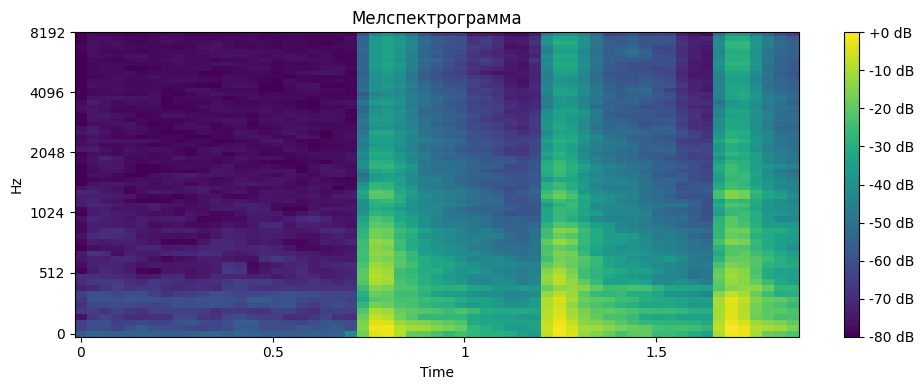

In [195]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
cmap = "viridis"

img = librosa.display.specshow(
    sample_x[0].numpy(force=True),
    sr=sample_rate,
    fmax=sample_rate // 2,
    ax=ax,
    x_axis='time',
    y_axis='mel',
    cmap=cmap,
)
ax.set(title='Мелспектрограмма')
ax.label_outer()

fig.colorbar(img, ax=ax, format="%+2.f dB")
plt.tight_layout()
plt.show()

In [196]:
from torch.utils.data import DataLoader

In [197]:
train_loader = DataLoader(train_dset, batch_size=41, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dset, batch_size=41, shuffle=False, num_workers=num_workers)

In [198]:
import time
from sklearn.metrics import accuracy_score

In [201]:
start_time = time.time()

n_epoch = 500 # увеличила количество эпох

set_random_state(random_state)

criterion = nn.CrossEntropyLoss()
network = DummyNetwork()

# можно попробовать другой optimizer, тоже считается улучшением
optimizer = optim.SGD(network.parameters(), lr=0.001)

train_loss = []
val_loss = []

train_acc = []
val_acc = []

for e in range(n_epoch):
    print(f'epoch #{e+1}')

    # train
    loss_list = []
    outputs = []
    targets = []
    for i_batch, sample_batched in enumerate(train_loader):
        x, y = sample_batched
        optimizer.zero_grad()

        output = network(x)
        outputs.append(output.argmax(axis=1))

        target = y
        targets.append(target)

        loss = criterion(output, target.long())
        loss_list.append(loss.item())
        loss.backward()
        optimizer.step()

    y_true = torch.hstack(targets).numpy(force=True)
    y_pred = torch.hstack(outputs).numpy(force=True)
    acc = accuracy_score(y_true, y_pred)

    train_loss.append(np.mean(loss_list))
    train_acc.append(acc)

    print(f'[train] mean loss: {train_loss[-1]}')
    print(f'[train] accuracy:  {acc}')

    loss_list = []
    outputs = []
    targets = []
    with torch.no_grad():
        for i_batch, sample_batched in enumerate(val_loader):
            x, y = sample_batched
            #optimizer.zero_grad()

            output = network(x)
            outputs.append(output.argmax(axis=1))

            target = y
            targets.append(target)

            loss = criterion(output, target.long())
            loss_list.append(loss.item())
            #loss.backward()
            #optimizer.step()

        y_true = torch.hstack(targets).numpy(force=True)
        y_pred = torch.hstack(outputs).numpy(force=True)
        acc = accuracy_score(y_true, y_pred)

        val_loss.append(np.mean(loss_list))
        val_acc.append(acc)

        print(f'[val] mean loss:   {val_loss[-1]}')
        print(f'[val] accuracy:    {acc}', end="\n\n")

print(f"Execution time: {(time.time() - start_time):.2f} seconds")

epoch #1
[train] mean loss: 3.646508915083749
[train] accuracy:  0.04488119683191552
[val] mean loss:   3.600461721420288
[val] accuracy:    0.059366754617414245

epoch #2
[train] mean loss: 3.481043131578536
[train] accuracy:  0.08653564095042535
[val] mean loss:   3.459583593266351
[val] accuracy:    0.07871591908531222

epoch #3
[train] mean loss: 3.30637332371303
[train] accuracy:  0.1387503666764447
[val] mean loss:   3.3689895399979184
[val] accuracy:    0.12225153913808268

epoch #4
[train] mean loss: 3.1800293070929393
[train] accuracy:  0.1601642710472279
[val] mean loss:   3.18706544807979
[val] accuracy:    0.15391380826737028

epoch #5
[train] mean loss: 3.0641107048307146
[train] accuracy:  0.1933118216485773
[val] mean loss:   3.1092460410935536
[val] accuracy:    0.16490765171503957

epoch #6
[train] mean loss: 2.969665479092371
[train] accuracy:  0.2015253740099736
[val] mean loss:   3.058185134615217
[val] accuracy:    0.1772207563764292

epoch #7
[train] mean loss: 2.

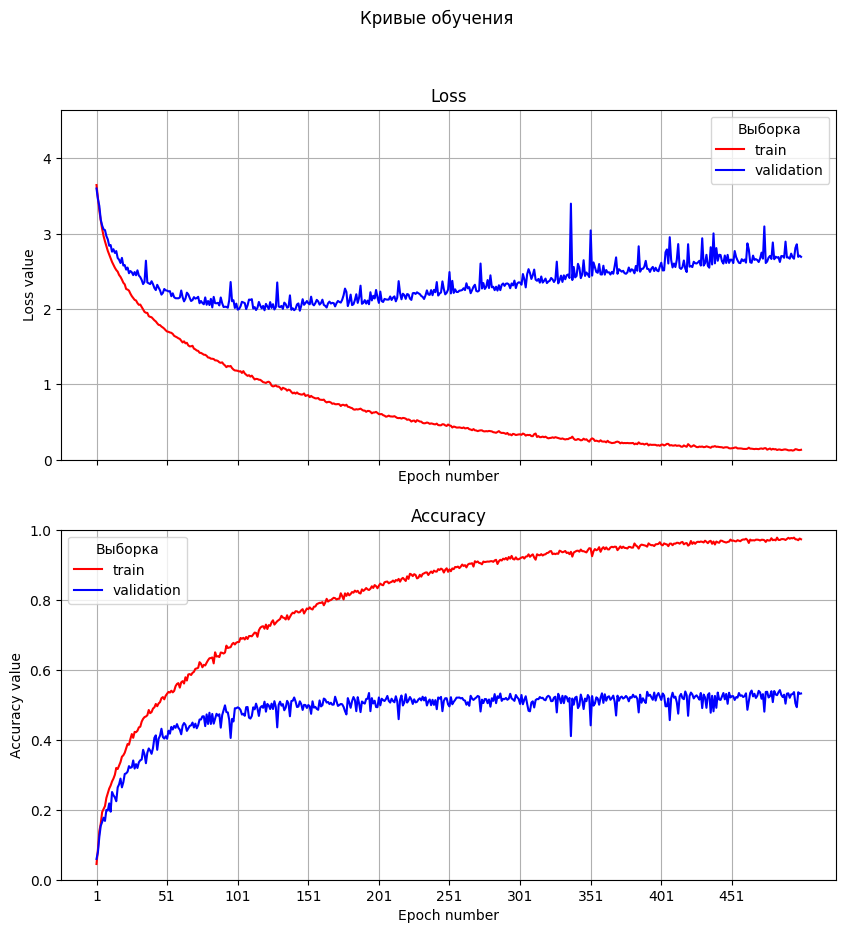

In [202]:
epochs = range(1, n_epoch+1)

fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

xticks = range(1, n_epoch+1, n_epoch // 10) if n_epoch > 10 else epochs

# draw loss
ax_top.plot(epochs, train_loss, 'r', label='train')
ax_top.plot(epochs, val_loss, 'b', label='validation')

ax_top.set(
    title='Loss',
    xlabel='Epoch number',
    ylabel='Loss value',
    ylim=[0, max(max(train_loss), max(val_loss)) + 1],
)
ax_top.legend(
    title="Выборка",
)
ax_top.grid()

# draw accuracy
ax_bottom.plot(epochs, train_acc, 'r', label='train')
ax_bottom.plot(epochs, val_acc, 'b', label='validation')

ax_bottom.set(
    title='Accuracy',
    xlabel='Epoch number',
    ylabel='Accuracy value',
    xticks=xticks,
    ylim=[0, 1],
)
ax_bottom.legend(
    title="Выборка",
)
ax_bottom.grid()

fig.suptitle("Кривые обучения")

plt.show()